# Correlation Skew and Quanto Hedge Fragility

**Research question:** Does correlation skew in vanilla option markets identify periods where ATM-based quanto hedges become more fragile, as measured by future instability in implied correlation or the quanto-relevant cross term?

---

**Case study:** ASML US Equity (ADR) / ASML NA Equity (Amsterdam) / EUR-USD

**Data:** 2016-01-04 → 2025-12-31 · 2,491 business days

This notebook is the **analysis layer only**. All data ingestion, cleaning, and derived-metric computation is handled by the existing pipeline (`run_pipeline.py` → `derived_dataset.csv`). We read that output and focus on interpretation.

---

### Definitions

| Symbol | Definition |
|---|---|
| $\rho_{\text{ATM}}$ | Implied equity–FX correlation from ATM vols: $(\sigma_{\text{ADR}}^2 - \sigma_{\text{loc}}^2 - \sigma_{\text{FX}}^2)\;/\;(2\,\sigma_{\text{loc}}\,\sigma_{\text{FX}})$ |
| $\rho_{\text{put}}$ | Same formula using 25-delta put vols for all three legs |
| $\rho_{\text{call}}$ | Same formula using 25-delta call vols for all three legs |
| Correlation skew | $\rho_{\text{put}} - \rho_{\text{call}}$ |
| $\Delta\rho_{N\text{d}}$ | Forward change in $\rho_{\text{ATM}}$ over $N$ business days |
| Cross-term | $2\,\rho\,\sigma_{\text{loc}}\,\sigma_{\text{FX}}$ (the quanto-specific variance component) |
| Hedge fragility | Measured by $|\Delta\rho|$ or $|\Delta\text{cross-term}|$ — large absolute moves indicate the ATM hedge becomes unreliable |

In [8]:
def decile_table(target_col: str, label: str) -> pd.DataFrame:
    """Compare unconditional vs top/bottom/extreme decile means."""
    s = df[target_col].dropna()
    rows = []
    unc_mean = s.mean()

    for name, mask_col in [("Unconditional", None),
                           ("Top decile (skew+)", "top_decile"),
                           ("Bottom decile (skew−)", "bottom_decile"),
                           ("Extreme decile (|skew|)", "extreme_decile")]:
        if mask_col is None:
            sub = s
        else:
            sub = s[df.loc[s.index, mask_col]]

        m = sub.mean()
        rows.append({
            "Subsample": name,
            "n": len(sub),
            "Mean": round(m, 5),
            "Median": round(sub.median(), 5),
            "Δ vs uncond": round(m - unc_mean, 5),
            "Ratio": round(m / unc_mean, 3) if abs(unc_mean) > 1e-10 else np.nan,
        })

    out = pd.DataFrame(rows).set_index("Subsample")
    out.columns.name = label
    return out

In [9]:
# ── Rho drift fragility ────────────────────────────────────────
print("=" * 70)
print("HEDGE FRAGILITY — |Δρ| by Correlation-Skew Decile")
print("=" * 70)
for h in ["1d", "5d", "20d"]:
    tbl = decile_table(f"abs_rho_drift_{h}", f"|Δρ| {h}")
    print(f"\n── Horizon: {h} ──")
    display(tbl)

HEDGE FRAGILITY — |Δρ| by Correlation-Skew Decile

── Horizon: 1d ──


|Δρ| 1d,n,Mean,Median,Δ vs uncond,Ratio
Subsample,,,,,
Unconditional,2490,0.17374,0.11613,0.00000,1.000
Top decile (skew+),250,0.22378,0.15035,0.05004,1.288
Bottom decile (skew−),249,0.20701,0.14218,0.03327,1.192
Extreme decile (|skew|),249,0.22888,0.15650,0.05515,1.317



── Horizon: 5d ──


|Δρ| 5d,n,Mean,Median,Δ vs uncond,Ratio
Subsample,,,,,
Unconditional,2486,0.21869,0.16564,0.00000,1.000
Top decile (skew+),249,0.25186,0.18412,0.03317,1.152
Bottom decile (skew−),249,0.23942,0.20209,0.02073,1.095
Extreme decile (|skew|),249,0.25001,0.19878,0.03132,1.143



── Horizon: 20d ──


|Δρ| 20d,n,Mean,Median,Δ vs uncond,Ratio
Subsample,,,,,
Unconditional,2471,0.26288,0.20578,0.00000,1.000
Top decile (skew+),242,0.33853,0.26522,0.07564,1.288
Bottom decile (skew−),249,0.26471,0.22968,0.00183,1.007
Extreme decile (|skew|),249,0.30024,0.25949,0.03735,1.142


In [10]:
# ── Cross-term drift fragility ────────────────────────────────
print("=" * 70)
print("HEDGE FRAGILITY — |Δ cross-term| by Correlation-Skew Decile")
print("=" * 70)
for h in ["1d", "5d", "20d"]:
    tbl = decile_table(f"abs_cross_term_drift_{h}", f"|Δ cross-term| {h}")
    print(f"\n── Horizon: {h} ──")
    display(tbl)

HEDGE FRAGILITY — |Δ cross-term| by Correlation-Skew Decile

── Horizon: 1d ──


|Δ cross-term| 1d,n,Mean,Median,Δ vs uncond,Ratio
Subsample,,,,,
Unconditional,2490,86.59559,47.71041,0.00000,1.000
Top decile (skew+),250,115.13874,57.00216,28.54315,1.330
Bottom decile (skew−),249,112.34368,66.21204,25.74809,1.297
Extreme decile (|skew|),249,129.17556,69.04979,42.57997,1.492



── Horizon: 5d ──


|Δ cross-term| 5d,n,Mean,Median,Δ vs uncond,Ratio
Subsample,,,,,
Unconditional,2486,104.82045,67.85517,0.00000,1.000
Top decile (skew+),249,115.35838,72.66250,10.53793,1.101
Bottom decile (skew−),249,131.80574,86.53605,26.98529,1.257
Extreme decile (|skew|),249,134.36839,85.19220,29.54794,1.282



── Horizon: 20d ──


|Δ cross-term| 20d,n,Mean,Median,Δ vs uncond,Ratio
Subsample,,,,,
Unconditional,2471,126.61618,91.97536,0.00000,1.000
Top decile (skew+),242,162.25714,124.70300,35.64096,1.281
Bottom decile (skew−),249,139.74770,103.57444,13.13151,1.104
Extreme decile (|skew|),249,159.80941,120.31140,33.19323,1.262


---
## F — Scatter Plots and OLS Regressions

We run bivariate regressions of fragility on correlation skew with **HC1 (White) robust standard errors** to account for heteroskedasticity.

$$
|\Delta\rho_{N\text{d}}| = \alpha + \beta \cdot \text{corr\_skew}_{1\text{m}} + \varepsilon
$$

In [11]:
def scatter_ols(x_col, y_col, xlabel, ylabel, title, color="#1f77b4"):
    """Scatter plot with OLS fit line and concise regression summary."""
    mask = df[x_col].notna() & df[y_col].notna()
    x = df.loc[mask, x_col]
    y = df.loc[mask, y_col]

    # OLS with robust SE
    X = sm.add_constant(x)
    res = sm.OLS(y, X).fit(cov_type="HC1")
    beta  = res.params.iloc[1]
    t_val = res.tvalues.iloc[1]
    p_val = res.pvalues.iloc[1]
    r     = x.corr(y)

    # Plot
    fig, ax = plt.subplots(figsize=(6.5, 5))
    ax.scatter(x, y, s=5, alpha=0.30, color=color, edgecolors="none")
    x_fit = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_fit, res.params.iloc[0] + beta * x_fit,
            color="black", lw=1.6, ls="--", label=f"β = {beta:.4f}")
    ax.axhline(0, color="grey", lw=0.5, ls="--", alpha=0.5)
    ax.axvline(0, color="grey", lw=0.5, ls="--", alpha=0.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11)
    ax.legend(loc="upper right", framealpha=0.8)
    fig.tight_layout()
    plt.show()

    # Compact summary
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    print(f"  n={len(x):,}  |  β={beta:.5f} (t={t_val:.2f}, p={p_val:.4f}){sig}  |  r={r:.4f}  |  R²={res.rsquared:.4f}")
    return res

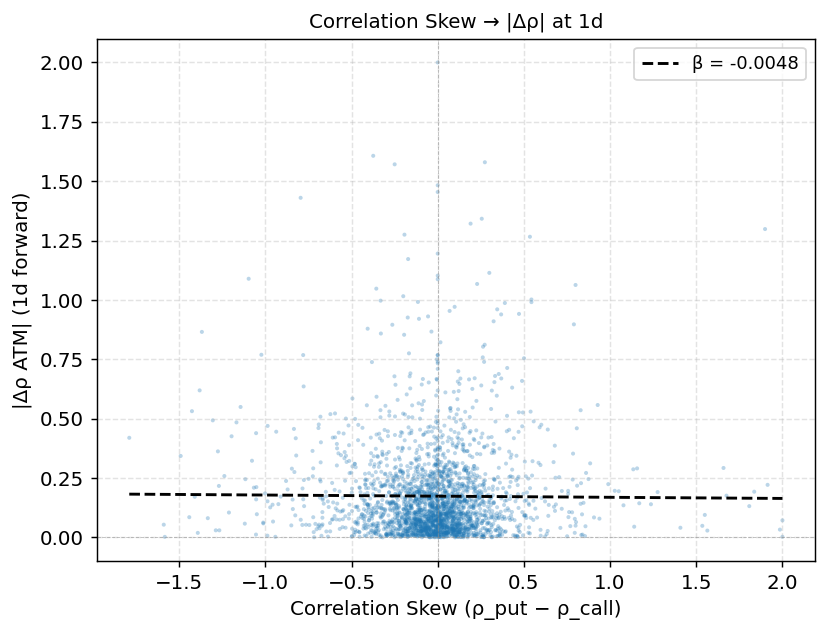

  n=2,490  |  β=-0.00477 (t=-0.33, p=0.7434)  |  r=-0.0084  |  R²=0.0001



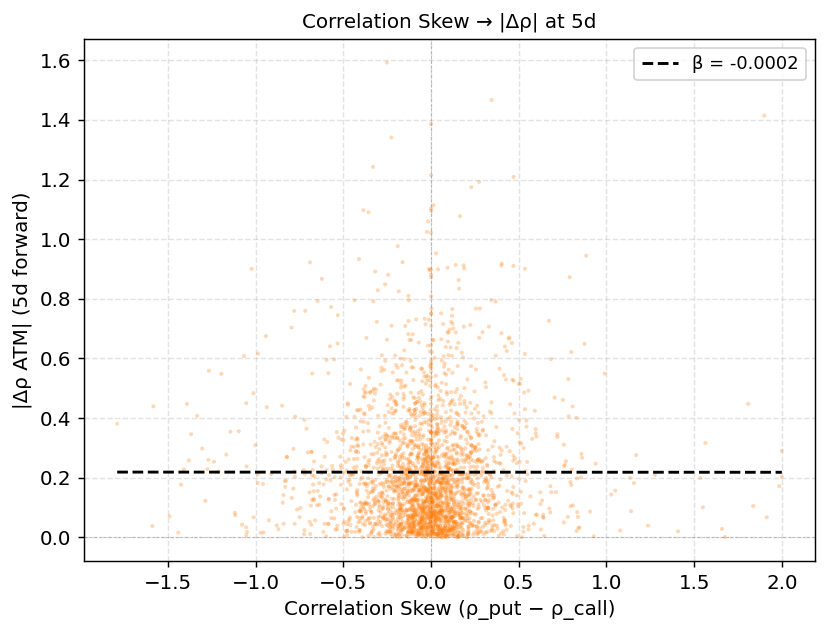

  n=2,486  |  β=-0.00017 (t=-0.01, p=0.9904)  |  r=-0.0003  |  R²=0.0000



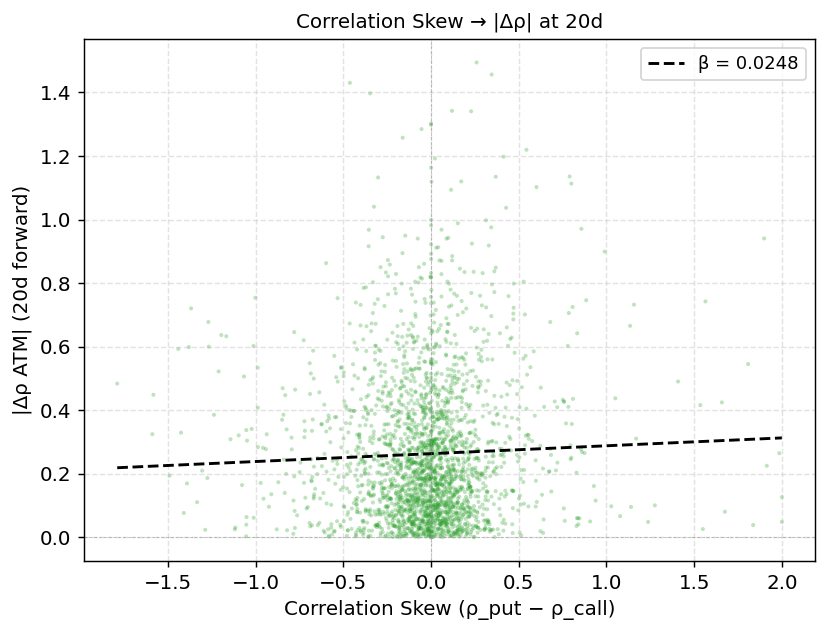

  n=2,471  |  β=0.02477 (t=1.68, p=0.0930)  |  r=0.0375  |  R²=0.0014



In [12]:
# F1–F3: corr_skew vs |Δρ| at three horizons
for h, clr in [("1d", "#1f77b4"), ("5d", "#ff7f0e"), ("20d", "#2ca02c")]:
    scatter_ols(
        "corr_skew_1m", f"abs_rho_drift_{h}",
        xlabel="Correlation Skew (ρ_put − ρ_call)",
        ylabel=f"|Δρ ATM| ({h} forward)",
        title=f"Correlation Skew → |Δρ| at {h}",
        color=clr,
    )
    print()

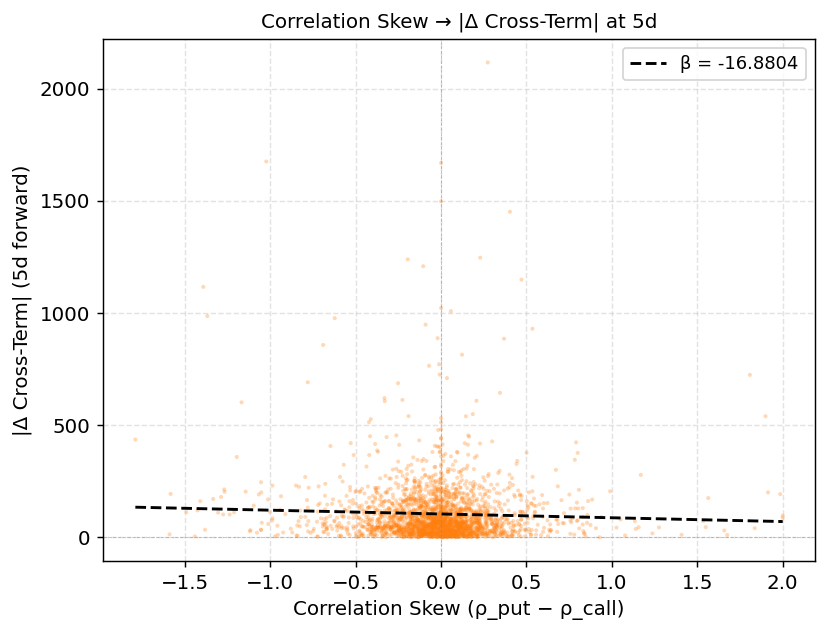

  n=2,486  |  β=-16.88041 (t=-1.39, p=0.1643)  |  r=-0.0414  |  R²=0.0017


In [13]:
# F4: corr_skew vs |Δ cross-term| at 5d
scatter_ols(
    "corr_skew_1m", "abs_cross_term_drift_5d",
    xlabel="Correlation Skew (ρ_put − ρ_call)",
    ylabel="|Δ Cross-Term| (5d forward)",
    title="Correlation Skew → |Δ Cross-Term| at 5d",
    color="#ff7f0e",
)

---
## F+ — Regression with Absolute Correlation Skew

The directional sign of the skew may matter less than its **magnitude**. We re-run the regressions using $|\text{corr\_skew}|$ as the predictor.

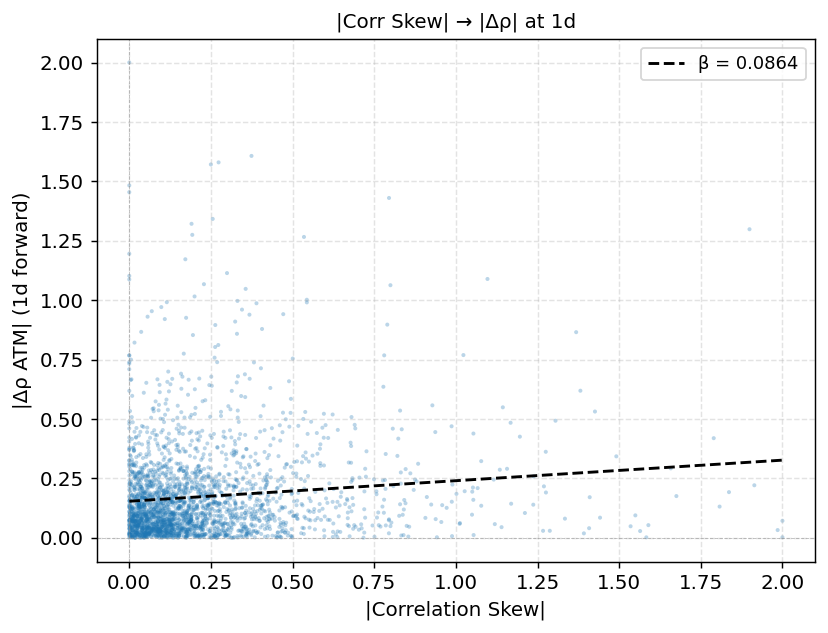

  n=2,490  |  β=0.08645 (t=4.43, p=0.0000)***  |  r=0.1147  |  R²=0.0131



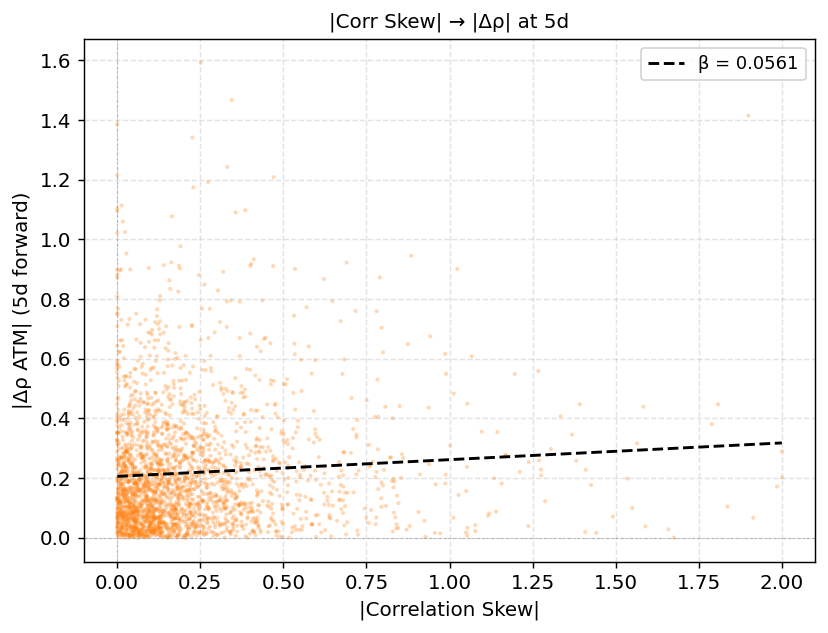

  n=2,486  |  β=0.05608 (t=2.95, p=0.0031)**  |  r=0.0717  |  R²=0.0051



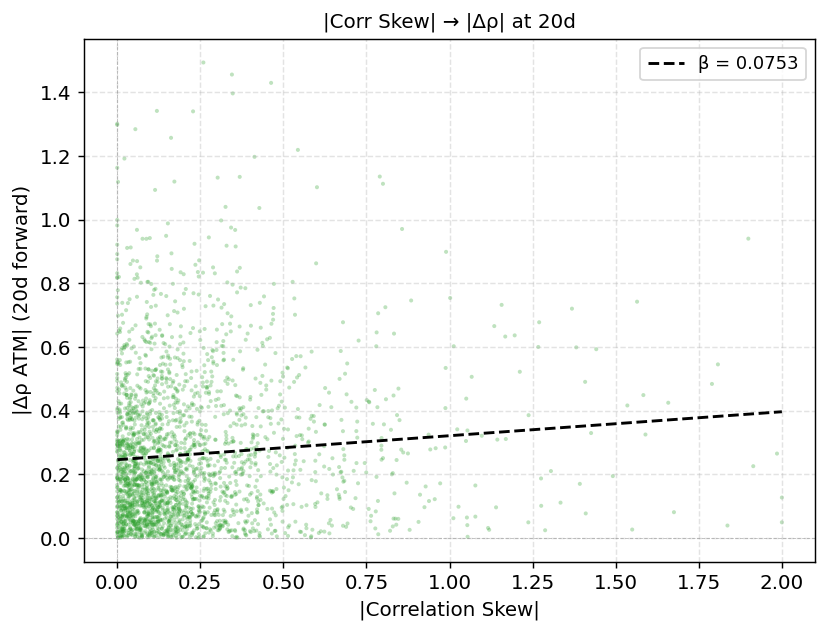

  n=2,471  |  β=0.07535 (t=3.98, p=0.0001)***  |  r=0.0861  |  R²=0.0074



In [14]:
df["abs_corr_skew_1m"] = df["corr_skew_1m"].abs()

for h, clr in [("1d", "#1f77b4"), ("5d", "#ff7f0e"), ("20d", "#2ca02c")]:
    scatter_ols(
        "abs_corr_skew_1m", f"abs_rho_drift_{h}",
        xlabel="|Correlation Skew|",
        ylabel=f"|Δρ ATM| ({h} forward)",
        title=f"|Corr Skew| → |Δρ| at {h}",
        color=clr,
    )
    print()

---
## G — Relationship with Other Surface Variables

Where does correlation skew come from? We check its relationship to:
- **ADR equity skew** (`adr_skew_1m = σ_P25 − σ_C25`)
- **Local equity skew** (`loc_skew_1m`)
- **FX risk reversal** (`fx_RR_1M = σ_C25 − σ_P25`)
- **ATM implied correlation** (`rho_1m`)

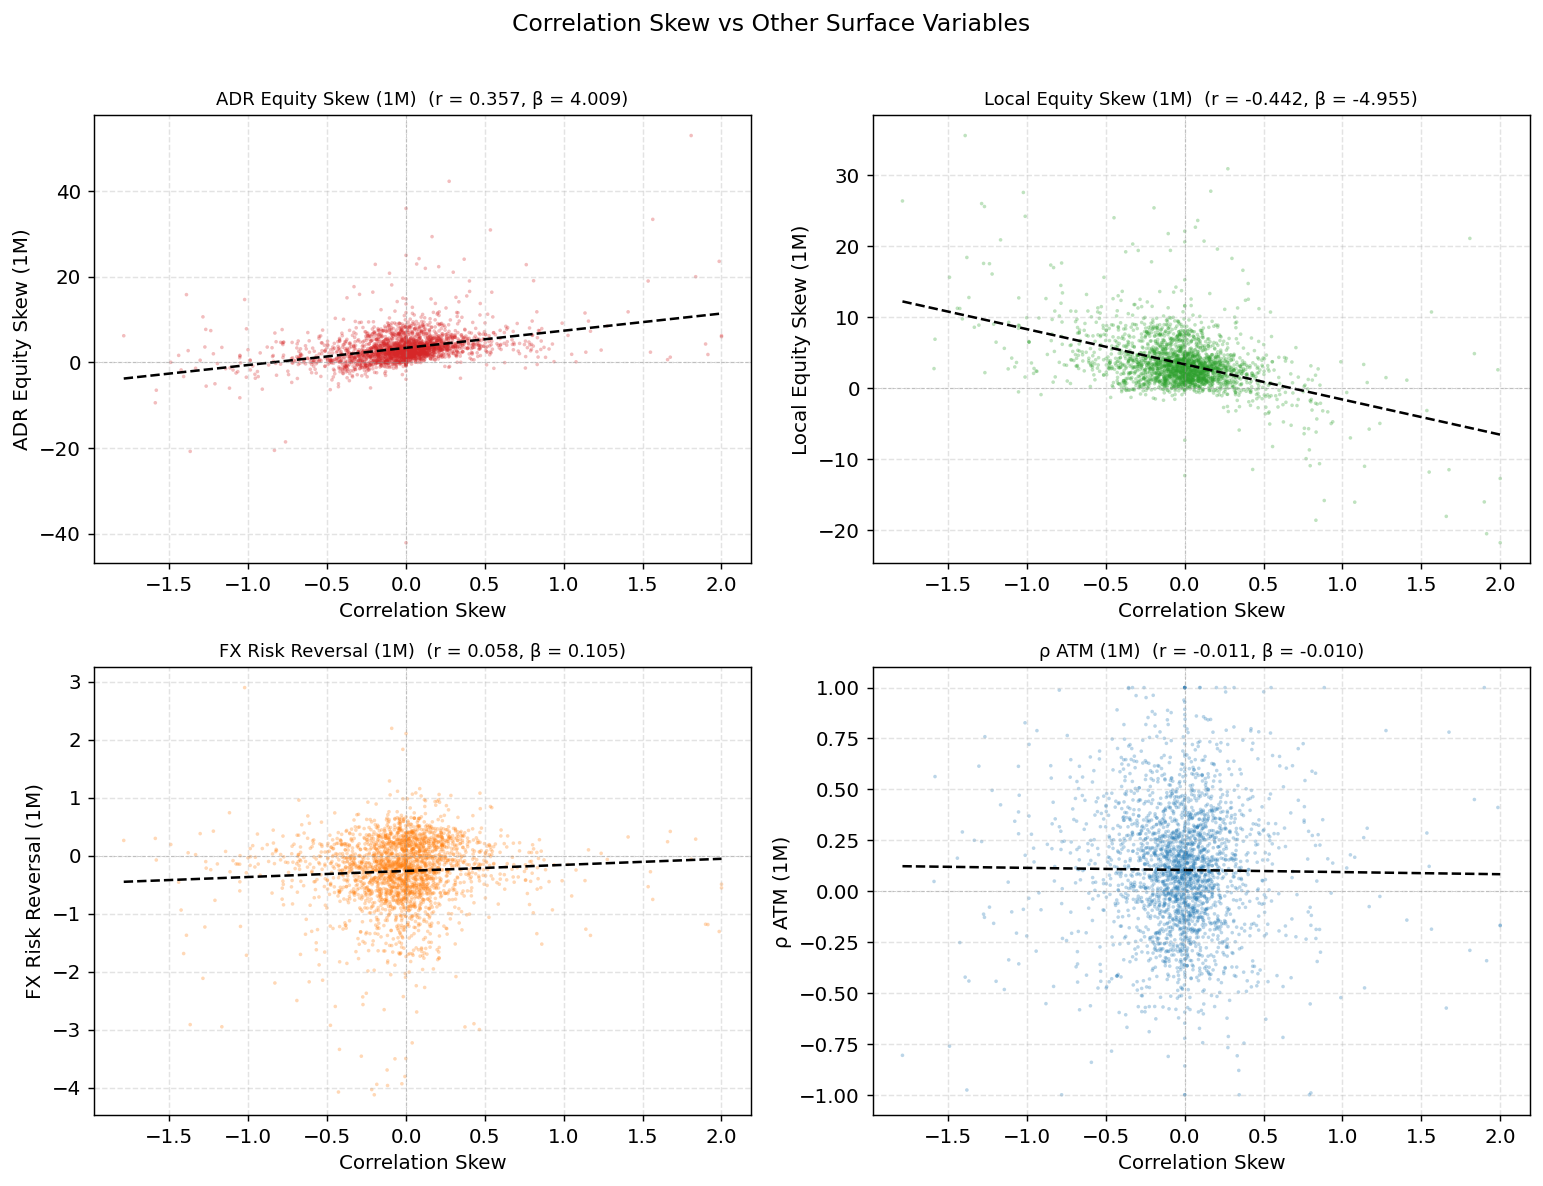

In [15]:
pairs = [
    ("adr_skew_1m",  "ADR Equity Skew (1M)",    "#d62728"),
    ("loc_skew_1m",  "Local Equity Skew (1M)",  "#2ca02c"),
    ("fx_RR_1M",     "FX Risk Reversal (1M)",   "#ff7f0e"),
    ("rho_1m",       "ρ ATM (1M)",              "#1f77b4"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, (col, label, color) in zip(axes.flat, pairs):
    mask = df["corr_skew_1m"].notna() & df[col].notna()
    x = df.loc[mask, "corr_skew_1m"]
    y = df.loc[mask, col]
    r = x.corr(y)

    ax.scatter(x, y, s=4, alpha=0.3, color=color, edgecolors="none")

    # Fit line
    coeffs = np.polyfit(x, y, 1)
    x_fit = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_fit, np.polyval(coeffs, x_fit), color="black", lw=1.4, ls="--")

    ax.set_xlabel("Correlation Skew")
    ax.set_ylabel(label)
    ax.set_title(f"{label}  (r = {r:.3f}, β = {coeffs[0]:.3f})", fontsize=10)
    ax.axhline(0, color="grey", lw=0.5, ls="--", alpha=0.4)
    ax.axvline(0, color="grey", lw=0.5, ls="--", alpha=0.4)

fig.suptitle("Correlation Skew vs Other Surface Variables", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

In [16]:
# Correlation matrix for the surface variables
surface_cols = ["corr_skew_1m", "adr_skew_1m", "loc_skew_1m", "fx_RR_1M", "rho_1m"]
corr_matrix = df[surface_cols].corr().round(3)
print("Pairwise correlations:")
display(corr_matrix)

Pairwise correlations:


,corr_skew_1m,adr_skew_1m,loc_skew_1m,fx_RR_1M,rho_1m
corr_skew_1m,1.000,0.357,-0.442,0.058,-0.011
adr_skew_1m,0.357,1.000,0.554,-0.120,-0.014
loc_skew_1m,-0.442,0.554,1.000,-0.164,-0.031
fx_RR_1M,0.058,-0.120,-0.164,1.000,0.053
rho_1m,-0.011,-0.014,-0.031,0.053,1.000


---
## H — Stress-Regime Check

Does the relationship strengthen when **vol is already elevated**? We define a stress regime as the top quartile of local equity ATM vol (1M), then re-run the decile analysis within that subsample.

In [17]:
# Define stress regime: top quartile of local ATM vol
vol_q75 = df["loc_ATM_1M"].quantile(0.75)
df["stress"] = df["loc_ATM_1M"] >= vol_q75

n_stress = df["stress"].sum()
print(f"Stress regime: loc_ATM_1M ≥ {vol_q75:.2f}  ({n_stress} days, {100*n_stress/len(df):.1f}%)")
print(f"Non-stress: {(~df['stress']).sum()} days")

Stress regime: loc_ATM_1M ≥ 36.01  (623 days, 25.0%)
Non-stress: 1868 days


In [18]:
def decile_table_filtered(target_col, regime_mask, regime_label):
    """Decile analysis within a subsample."""
    sub = df.loc[regime_mask].copy()
    s = sub[target_col].dropna()
    unc_mean = s.mean()

    # Re-compute decile thresholds within subsample
    skew = sub["corr_skew_z"].dropna()
    q10_sub = skew.quantile(0.10)
    q90_sub = skew.quantile(0.90)

    rows = []
    for name, mask in [(f"All {regime_label}", pd.Series(True, index=sub.index)),
                       ("Top decile (skew+)", sub["corr_skew_z"] >= q90_sub),
                       ("Bottom decile (skew−)", sub["corr_skew_z"] <= q10_sub)]:
        vals = s[mask.reindex(s.index, fill_value=False)]
        m = vals.mean()
        rows.append({
            "Subsample": name,
            "n": len(vals),
            "Mean": round(m, 5),
            "Δ vs subsample uncond": round(m - unc_mean, 5),
            "Ratio": round(m / unc_mean, 3) if abs(unc_mean) > 1e-10 else np.nan,
        })

    return pd.DataFrame(rows).set_index("Subsample")


print("=" * 70)
print("STRESS REGIME: |Δρ| at 5d by Corr-Skew Decile")
print("=" * 70)

print("\n── Stress (high vol) ──")
display(decile_table_filtered("abs_rho_drift_5d", df["stress"], "stress"))

print("\n── Non-stress (normal vol) ──")
display(decile_table_filtered("abs_rho_drift_5d", ~df["stress"], "non-stress"))

STRESS REGIME: |Δρ| at 5d by Corr-Skew Decile

── Stress (high vol) ──


,n,Mean,Δ vs subsample uncond,Ratio
Subsample,,,,
All stress,619,0.24045,0.00000,1.000
Top decile (skew+),63,0.29796,0.05751,1.239
Bottom decile (skew−),62,0.27473,0.03428,1.143



── Non-stress (normal vol) ──


,n,Mean,Δ vs subsample uncond,Ratio
Subsample,,,,
All non-stress,1867,0.21147,0.00000,1.000
Top decile (skew+),186,0.23468,0.02321,1.110
Bottom decile (skew−),187,0.22668,0.01521,1.072


In [19]:
# Repeat for cross-term drift at 5d
print("=" * 70)
print("STRESS REGIME: |Δ Cross-Term| at 5d by Corr-Skew Decile")
print("=" * 70)

print("\n── Stress (high vol) ──")
display(decile_table_filtered("abs_cross_term_drift_5d", df["stress"], "stress"))

print("\n── Non-stress (normal vol) ──")
display(decile_table_filtered("abs_cross_term_drift_5d", ~df["stress"], "non-stress"))

STRESS REGIME: |Δ Cross-Term| at 5d by Corr-Skew Decile

── Stress (high vol) ──


,n,Mean,Δ vs subsample uncond,Ratio
Subsample,,,,
All stress,619,175.65898,0.00000,1.000
Top decile (skew+),63,206.10724,30.44826,1.173
Bottom decile (skew−),62,235.28907,59.63009,1.339



── Non-stress (normal vol) ──


,n,Mean,Δ vs subsample uncond,Ratio
Subsample,,,,
All non-stress,1867,81.33408,0.00000,1.000
Top decile (skew+),186,83.56393,2.22985,1.027
Bottom decile (skew−),187,92.13591,10.80183,1.133


---
## Summary

### What was reused from the existing pipeline
- `derived_dataset.csv` (2,491 × 42): all raw vols, spots, ATM/wing rho, correlation skew, rho drift, cross-term drift, equity skew — computed by `compute_derived.py`
- No pipeline code was duplicated or re-executed

### What this notebook newly computes
- `abs_rho_drift_{1d,5d,20d}` — absolute forward rho change (hedge-fragility proxy)
- `abs_cross_term_drift_{1d,5d,20d}` — absolute forward cross-term change
- `corr_skew_z` — z-scored correlation skew
- `abs_corr_skew_1m` — magnitude of correlation skew
- Decile labels: `top_decile`, `bottom_decile`, `extreme_decile`
- `stress` — top-quartile local ATM vol regime flag

### Main tables
- **Section E**: Decile comparison tables for |Δρ| and |Δ cross-term| at 1d / 5d / 20d — the core result
- **Section G**: Pairwise correlation matrix of surface variables
- **Section H**: Stress-regime conditional decile tables

### Main plots
- **B1**: ATM vs put-wing vs call-wing rho time series
- **B2**: Correlation skew time series with rolling mean
- **F1–F3**: Scatter + OLS of corr skew → |Δρ| at 1d / 5d / 20d
- **F4**: Scatter + OLS of corr skew → |Δ cross-term| at 5d
- **F+**: Scatter + OLS using |corr skew| as predictor
- **G**: 2×2 panel — corr skew vs equity skew, FX RR, ATM rho

### Caveats
1. **Rho clipping**: raw implied ρ is clipped to [−1, 1]; extreme triangle violations are truncated
2. **Forward-looking drift**: `rho_drift_Nd` uses `shift(-N)`, so it is an ex-post label — not a tradeable signal without proper backtesting
3. **Forward-fill**: up to 3 business days of stale data during holidays
4. **Vols in percentage points**: delta_var and cross_term are in pp² units; rho is scale-invariant
5. **No overlapping-window correction**: the 5d and 20d drift columns are serially correlated by construction; OLS t-stats should be interpreted with caution despite robust SEs